# **Mini-Proyecto:** Control de un Sistema Térmico MIMO mediante Desacoplo Estático

**Autores:**

*   Daniel Esteban Tirado Rojas

*   Luis Alberto Ardila Páez

*   Jose Leonardo Pérez Poveda

**Sistemas de Control Continuo**

**Facultad de Ingeniería**

**Universidad de Antioquia**

---

In [1]:
%pip install control pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct
import pandas as pd
from scipy.linalg import block_diag
from scipy.optimize import fsolve, least_squares
s = ct.TransferFunction.s

## **3. Parte A:** Identificación Experimental del Sistema MIMO

Se aplicó un escalón en el calentador 1 y se almacenaron los datos sensados en el archivo `data_Q1.txt`. De manera similar se hizo para el calentador 2, almacenando su salida en `data_Q2.txt`.

A continuación, se toman las respuestas experimentales de los dos ensayos del laboratorio y se identifican los cuatro canales de la matriz de transferencia: $G_{11}(s)$, $G_{21}(s)$, $G_{12}(s)$ y $G_{22}(s)$.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import control as ct


def fopdt(t, K, tau, theta, t_step, delta_u, y0):
    tr = t - t_step - theta
    y = y0 + K * delta_u * (1 - np.exp(-tr / tau))
    return np.where(tr > 0, y, y0)


def estimar_inicial(t, y, t_step, delta_u):
    y0 = np.mean(y[t < t_step]) if np.any(t < t_step) else np.mean(y[:20])
    yss = np.mean(y[-20:])

    K = (yss - y0) / delta_u

    cambio = yss - y0
    y10 = y0 + 0.10 * cambio
    y63 = y0 + 0.632 * cambio

    idx10 = np.argmin(np.abs(y - y10))
    idx63 = np.argmin(np.abs(y - y63))

    theta = max(t[idx10] - t_step, 0)
    tau = max(t[idx63] - t_step - theta, 1e-6)

    return K, tau, theta, y0, yss


def optimizar_fopdt(t, y, t_step, delta_u, theta_max=None):
    K0, tau0, theta0, y0, yss = estimar_inicial(t, y, t_step, delta_u)

    if theta_max is None:
        theta_max = 0.35 * (t[-1] - t[0])

    def error(p):
        K, tau, theta = p
        return fopdt(t, K, tau, theta, t_step, delta_u, y0) - y

    p0 = [K0, tau0, theta0]

    lb = [-np.inf, 1e-6, 0]
    ub = [np.inf, t[-1] - t[0], theta_max]

    res = least_squares(error, p0, bounds=(lb, ub))

    return {
        "Inicial": [K0, tau0, theta0],
        "Opt": res.x,
        "y0": y0,
        "yss": yss
    }


def crear_tf(K, tau, theta, pade_order=3):
    s = ct.TransferFunction.s
    G_base = K / (tau*s + 1)
    delay = ct.tf(*ct.pade(theta, pade_order))
    return ct.series(delay, G_base)

def graficar_datos_y_modelos(
    tiempo_q1, temp1_q1, temp2_q1,
    tiempo_q2, temp1_q2, temp2_q2,
    G11_par, G21_par, G12_par, G22_par,
    t_step_q1, delta_q1,
    t_step_q2, delta_q2
):
    y11 = fopdt(tiempo_q1, *G11_par["Opt"], t_step_q1, delta_q1, G11_par["y0"])
    y21 = fopdt(tiempo_q1, *G21_par["Opt"], t_step_q1, delta_q1, G21_par["y0"])

    y12 = fopdt(tiempo_q2, *G12_par["Opt"], t_step_q2, delta_q2, G12_par["y0"])
    y22 = fopdt(tiempo_q2, *G22_par["Opt"], t_step_q2, delta_q2, G22_par["y0"])

    fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))

    ax[0].plot(tiempo_q1, temp1_q1, label="Temp1 G11")
    ax[0].plot(tiempo_q1, y11, "--", label="Aprox G11")
    ax[0].plot(tiempo_q1, temp2_q1, label="Temp2 G21")
    ax[0].plot(tiempo_q1, y21, "--", label="Aprox G21")

    ax[0].set_title("Lectura de data_Q1.txt")
    ax[0].set_xlabel("Tiempo [s]")
    ax[0].set_ylabel("Temperatura [°C]")
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(tiempo_q2, temp1_q2, label="Temp1 G12")
    ax[1].plot(tiempo_q2, y12, "--", label="Aprox G12")
    ax[1].plot(tiempo_q2, temp2_q2, label="Temp2 G22")
    ax[1].plot(tiempo_q2, y22, "--", label="Aprox G22")

    ax[1].set_title("Lectura de data_Q2.txt")
    ax[1].set_xlabel("Tiempo [s]")
    ax[1].set_ylabel("Temperatura [°C]")
    ax[1].grid(True)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

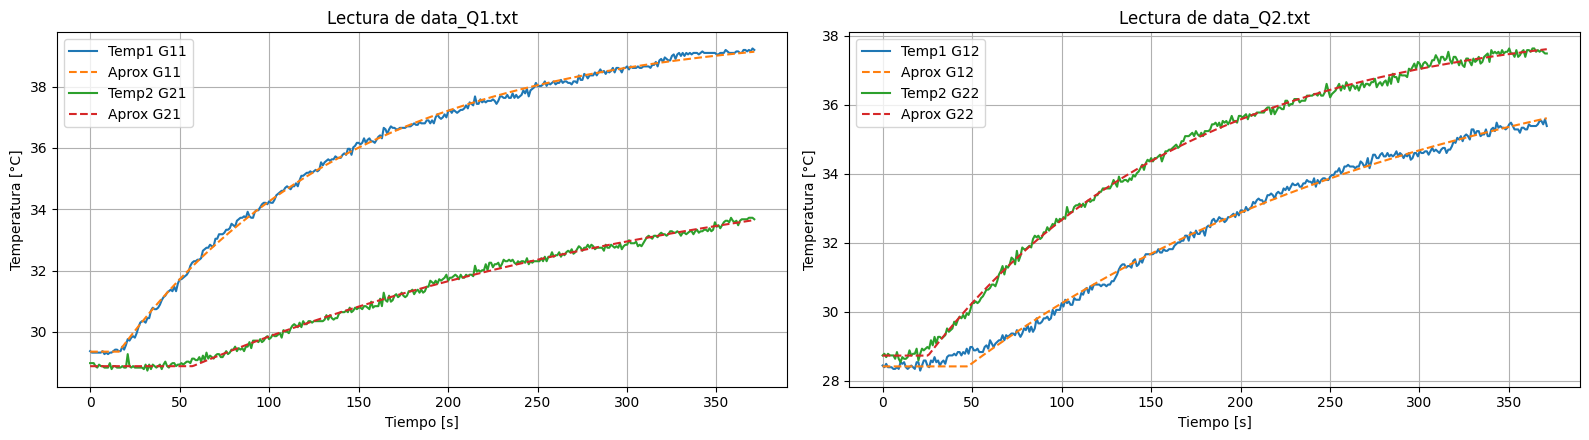

In [21]:
# EXTRAER DATOS

# data_Q1.txt
ruta_q1 = "data_Q1.txt"
data_q1 = np.genfromtxt(ruta_q1, delimiter=",", skip_header=1, encoding="latin1")

tiempo_q1 = data_q1[:, 0]
temp1_q1 = data_q1[:, 3]
temp2_q1 = data_q1[:, 4]

# data_Q2.txt
ruta_q2 = "data_Q2.txt"
data_q2 = np.genfromtxt(ruta_q2, delimiter=",", skip_header=1, encoding="latin1")

tiempo_q2 = data_q2[:, 0]
temp1_q2 = data_q2[:, 3]
temp2_q2 = data_q2[:, 4]

# ESTIMAR PARÁMETROS
t_step_q1 = 0
delta_q1 = 40

t_step_q2 = 0
delta_q2 = 40

G11_par = optimizar_fopdt(tiempo_q1, temp1_q1, t_step_q1, delta_q1, theta_max=80)
G21_par = optimizar_fopdt(tiempo_q1, temp2_q1, t_step_q1, delta_q1, theta_max=120)

G12_par = optimizar_fopdt(tiempo_q2, temp1_q2, t_step_q2, delta_q2, theta_max=120)
G22_par = optimizar_fopdt(tiempo_q2, temp2_q2, t_step_q2, delta_q2, theta_max=120)

# APROXIMACIÓN PADÉ
pade_order = 3

G11 = crear_tf(*G11_par["Opt"], pade_order)
G12 = crear_tf(*G12_par["Opt"], pade_order)
G21 = crear_tf(*G21_par["Opt"], pade_order)
G22 = crear_tf(*G22_par["Opt"], pade_order)

modelos = {
    "G11": G11_par,
    "G12": G12_par,
    "G21": G21_par,
    "G22": G22_par
}

graficar_datos_y_modelos(
    tiempo_q1, temp1_q1, temp2_q1,
    tiempo_q2, temp1_q2, temp2_q2,
    G11_par, G21_par, G12_par, G22_par,
    t_step_q1, delta_q1,
    t_step_q2, delta_q2
)

## **4. Parte B:** Construcción del Modelo MIMO

In [20]:
G_mimo = ct.tf([
    [G11, G12],
    [G21, G22]
])

print(G_mimo)

<TransferFunction>: sys[165]
Inputs (2): ['u[0]', 'u[1]']
Outputs (2): ['y[0]', 'y[1]']

Input 1 to output 1:

     -0.2631 s^3 + 0.1967 s^2 - 0.06124 s + 0.007629
  -----------------------------------------------------
  133.9 s^4 + 101.1 s^3 + 31.92 s^2 + 4.116 s + 0.02899

Input 1 to output 2:

    -0.1855 s^3 + 0.03885 s^2 - 0.003391 s + 0.0001184
  -------------------------------------------------------
  305.3 s^4 + 64.94 s^3 + 5.789 s^2 + 0.2131 s + 0.000638

Input 2 to output 1:

   -0.2555 s^3 + 0.06444 s^2 - 0.006772 s + 0.0002847
  -----------------------------------------------------
  266 s^4 + 68.09 s^3 + 7.303 s^2 + 0.3229 s + 0.001114

Input 2 to output 2:

     -0.2446 s^3 + 0.1153 s^2 - 0.02266 s + 0.001781
  -----------------------------------------------------
  145.2 s^4 + 69.48 s^3 + 13.93 s^2 + 1.15 s + 0.007281


## **7. Parte E:** Diseño del Desacoplador

In [ ]:
K11 = ct.dcgain(G11)
K12 = ct.dcgain(G12)
K21 = ct.dcgain(G21)
K22 = ct.dcgain(G22)

D12 = -K12/K11
D21 = -K21/K22

D = [[1,D12],
      [D21, 1]]
D

[[1, np.float64(-0.970963760388639)], [np.float64(-0.18550908585427073), 1]]

## **8. Parte F: Diseño PID**

In [116]:
def specs_polos(OS=10, Ts=120):
    OS = OS / 100
    zeta = -np.log(OS) / np.sqrt(np.pi**2 + np.log(OS)**2)
    wn = 4 / (zeta * Ts)

    sigma = zeta * wn
    wd = wn * np.sqrt(1 - zeta**2)

    sd = -sigma + 1j * wd

    return zeta, wn, sd

def disenar_pid_lgr(K, tau, OS=10, Ts=120):
    zeta, wn, sd = specs_polos(OS, Ts)

    alpha = 2 * zeta * wn
    Td = tau / 100

    A = (alpha * tau - 1) / (1 - alpha * Td)

    Kp = A / K
    Ti = A / (wn**2 * (tau + A * Td))

    Ki = Kp / Ti
    Kd = Kp * Td

    return {
        "Kp": Kp,
        "Ti": Ti,
        "Td": Td,
        "Ki": Ki,
        "Kd": Kd,
        "zeta": zeta,
        "wn": wn,
        "sd": sd
    }

def pid_tf(Kp, Ki, Kd, tfiltro=0.05):
    s = ct.TransferFunction.s
    return Kp + Ki/s + (Kd*s)/(tfiltro*s + 1)

def planta_tf(K, tau):
    s = ct.TransferFunction.s
    return K / (tau*s + 1)

def analizar_pid(K, tau, nombre, OS=10, Ts=120):
    r = disenar_pid_lgr(K, tau, OS, Ts)

    G = planta_tf(K, tau)
    C = C = pid_tf(r["Kp"], r["Ki"], r["Kd"], tfiltro=0.005)

    L = C * G
    T = ct.feedback(L, 1)

    print(nombre)
    print(f"Kp = {r['Kp']:.4f}")
    print(f"Ti = {r['Ti']:.4f}")
    print(f"Td = {r['Td']:.4f}")
    print(f"Ki = {r['Ki']:.4f}")
    print(f"Kd = {r['Kd']:.4f}")
    print(f"Polo deseado = {r['sd']:.4f}")
    print()

    # plt.figure()
    # ct.root_locus(L, grid=True)
    # plt.plot(np.real(r["sd"]), np.imag(r["sd"]), "rx", markersize=10)
    # plt.plot(np.real(r["sd"]), -np.imag(r["sd"]), "rx", markersize=10)
    # plt.title(f"LGR - {nombre}")
    # plt.show()

    # t, y = ct.step_response(T)

    # plt.figure()
    # plt.plot(t, y)
    # plt.grid(True)
    # plt.xlabel("Tiempo [s]")
    # plt.ylabel("Salida")
    # plt.title(f"Respuesta al escalón - {nombre}")
    # plt.show()

    return C, G, L, T, r

In [132]:
tau_11 = 159.0457
tau_22 = 169.0153

print("FUNCIÓN DE TRANSFERENCIA Y PARÁMETROS PARA C1: ")
C1, G11_base, L1, T1, pid1 = analizar_pid(
    K11, tau_11, "Canal G11 - Controlador C1"
)
print(C1)

print("FUNCIÓN DE TRANSFERENCIA Y PARÁMETROS PARA C2: ")
C2, G22_base, L2, T2, pid2 = analizar_pid(
    K22, tau_22, "Canal G22 - Controlador C2",
    OS=5, Ts=200
)
print(C2)

FUNCIÓN DE TRANSFERENCIA Y PARÁMETROS PARA C1: 
Canal G11 - Controlador C1
Kp = 40.8251
Ti = 19.1821
Td = 1.5905
Ki = 2.1283
Kd = 64.9306
Polo deseado = -0.0333+0.0455j

<TransferFunction>: sys[2784]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  65.13 s^2 + 40.84 s + 2.128
  ---------------------------
         0.005 s^2 + s
FUNCIÓN DE TRANSFERENCIA Y PARÁMETROS PARA C2: 
Canal G22 - Controlador C2
Kp = 25.2599
Ti = 40.9902
Td = 1.6902
Ki = 0.6162
Kd = 42.6931
Polo deseado = -0.0200+0.0210j

<TransferFunction>: sys[2805]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  42.82 s^2 + 25.26 s + 0.6162
  ----------------------------
         0.005 s^2 + s


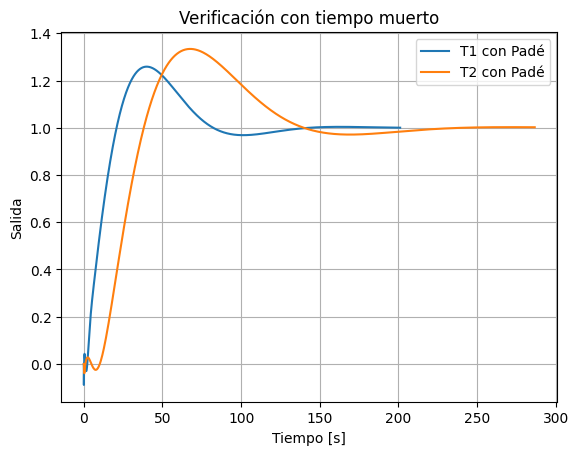

In [130]:
def planta_fopdt_pade(K, tau, theta, orden=3):
    s = ct.TransferFunction.s
    G_base = K / (tau*s + 1)
    delay = ct.tf(*ct.pade(theta, orden))
    return delay * G_base

theta_11 = 2.9464
theta_22 = 12.5972

G11_pade = planta_fopdt_pade(K11, tau_11, theta_11)
G22_pade = planta_fopdt_pade(K22, tau_22, theta_22)

T1_pade = ct.feedback(C1 * G11_pade, 1)
T2_pade = ct.feedback(C2 * G22_pade, 1)

t1, y1 = ct.step_response(T1_pade)
t2, y2 = ct.step_response(T2_pade)

plt.figure()
plt.plot(t1, y1, label="T1 con Padé")
plt.plot(t2, y2, label="T2 con Padé")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.title("Verificación con tiempo muerto")
plt.legend()
plt.show()

In [ ]:
"""
=======================================================================
 COMPARACIÓN: SISTEMA CON Y SIN DESACOPLADOR ESTÁTICO
 Planta Térmica MIMO 2×2 — Parte G del Mini-Proyecto
=======================================================================
 Simula el lazo cerrado MIMO en dos casos:

   Caso 1 — Sin desacoplador:   Q1=V1,  Q2=V2
   Caso 2 — Con desacoplador:   Q1=V1+d12·V2,  Q2=d21·V1+V2

 Método de simulación:
   ct.interconnect   → interconexión formal del sistema MIMO
   ct.forced_response → simulación ante entradas arbitrarias

 Entradas (escalones secuenciales para ver el acoplamiento):
   r1 = 1 desde t=0    (setpoint T1)
   r2 = 1 desde t=500s (setpoint T2)
=======================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import control


# ───────────────────────────────────────────────────────────────
#  CONFIGURACIÓN
# ───────────────────────────────────────────────────────────────

PADE_ORDER = 2
T_FILTER   = 0.005

PLANT_PARAMS = {
    "G11": (2.2049, 185.13,  7.71),
    "G12": (0.4349, 287.78, 85.59),
    "G21": (0.8564, 311.15, 64.46),
    "G22": (2.0477, 161.82,  1.94),
}

PID_PARAMS = {
    "C1": (1.10018, 0.005821, 4.1547),
    "C2": (1.21007, 0.007433, 1.1668),
}

d12 = -0.4349 / 2.2049   # −K12/K11
d21 = -0.8564 / 2.0477   # −K21/K22


# ───────────────────────────────────────────────────────────────
#  1.  FUNCIONES DE TRANSFERENCIA
# ───────────────────────────────────────────────────────────────

def build_plant(Kp, tau, theta):
    """FOPDT con retardo aproximado por Padé orden 2."""
    num_p, den_p = control.pade(theta, PADE_ORDER)
    return control.tf([Kp], [tau, 1.0]) * control.tf(num_p, den_p)


def build_controller(Kp_c, Ki, Kd):
    """PID filtrado: C(s) = Kp + Ki/s + Kd·s/(T·s+1)."""
    T   = T_FILTER
    num = [Kp_c*T + Kd,  Kp_c + Ki*T,  Ki]
    den = [T, 1.0, 0.0]
    return control.tf(num, den)


def named_ss(tf, inp, out, name):
    """Convierte TF a StateSpace con nombres de puertos para interconnect."""
    ss = control.tf2ss(tf)
    return control.ss(ss.A, ss.B, ss.C, ss.D,
                      inputs=[inp], outputs=[out], name=name)


# ───────────────────────────────────────────────────────────────
#  2.  CONSTRUCCIÓN DEL LAZO CERRADO MIMO CON ct.interconnect
#
#  Bloques del sistema:
#    C1, C2       — controladores PID
#    G11..G22     — planta MIMO (4 canales FOPDT con Padé)
#    D12, D21     — ganancias del desacoplador
#    sumQ1, sumQ2 — suma de señales de control
#    sumT1, sumT2 — suma de salidas de planta (superposición)
#    sumE1, sumE2 — cálculo del error  e = r − y
# ───────────────────────────────────────────────────────────────

def build_closed_loop(decoupler: bool):
    """
    Construye el sistema MIMO en lazo cerrado usando ct.interconnect.
    Con desacoplador: Q1 = V1 + d12·V2,  Q2 = d21·V1 + V2
    Sin desacoplador: Q1 = V1,            Q2 = V2
    """
    # Controladores
    C1 = named_ss(build_controller(*PID_PARAMS["C1"]), "e1", "V1", "C1")
    C2 = named_ss(build_controller(*PID_PARAMS["C2"]), "e2", "V2", "C2")

    # Plantas
    G11 = named_ss(build_plant(*PLANT_PARAMS["G11"]), "Q1", "T1_G11", "G11")
    G12 = named_ss(build_plant(*PLANT_PARAMS["G12"]), "Q2", "T1_G12", "G12")
    G21 = named_ss(build_plant(*PLANT_PARAMS["G21"]), "Q1", "T2_G21", "G21")
    G22 = named_ss(build_plant(*PLANT_PARAMS["G22"]), "Q2", "T2_G22", "G22")

    # Superposición: T1 = G11·Q1 + G12·Q2,  T2 = G21·Q1 + G22·Q2
    sumT1 = control.summing_junction(
        inputs=["T1_G11", "T1_G12"], output="T1", name="sumT1")
    sumT2 = control.summing_junction(
        inputs=["T2_G21", "T2_G22"], output="T2", name="sumT2")

    # Errores: e = r − y
    sumE1 = control.summing_junction(
        inputs=["r1", "-T1"], output="e1", name="sumE1")
    sumE2 = control.summing_junction(
        inputs=["r2", "-T2"], output="e2", name="sumE2")

    if decoupler:
        # Ganancias del desacoplador estático
        D12 = named_ss(control.tf([d12], [1]), "V2", "d12V2", "D12")
        D21 = named_ss(control.tf([d21], [1]), "V1", "d21V1", "D21")

        sumQ1 = control.summing_junction(
            inputs=["V1", "d12V2"], output="Q1", name="sumQ1")
        sumQ2 = control.summing_junction(
            inputs=["V2", "d21V1"], output="Q2", name="sumQ2")

        components = [C1, C2, D12, D21, G11, G12, G21, G22,
                      sumQ1, sumQ2, sumT1, sumT2, sumE1, sumE2]
    else:
        sumQ1 = control.summing_junction(
            inputs=["V1"], output="Q1", name="sumQ1")
        sumQ2 = control.summing_junction(
            inputs=["V2"], output="Q2", name="sumQ2")

        components = [C1, C2, G11, G12, G21, G22,
                      sumQ1, sumQ2, sumT1, sumT2, sumE1, sumE2]

    return control.interconnect(
        components, inplist=["r1", "r2"], outlist=["T1", "T2", "Q1", "Q2"])


# ───────────────────────────────────────────────────────────────
#  3.  SIMULACIÓN CON ct.forced_response
# ───────────────────────────────────────────────────────────────

print("Construyendo sistemas MIMO...")
sys_con = build_closed_loop(decoupler=True)
sys_sin = build_closed_loop(decoupler=False)

# Escalones secuenciales: r1 desde t=0, r2 desde t=500s
# Esto permite ver claramente el acoplamiento:
# cuando sube r2, si hay acoplamiento T1 también se perturba
t   = np.linspace(0, 2000, 4000)
r1  = np.ones_like(t)
r2  = np.zeros_like(t);  r2[t >= 500] = 1.0
U   = np.vstack([r1, r2])

print("Simulando con desacoplador...")
t_out, y_con = control.forced_response(sys_con, T=t, U=U)

print("Simulando sin desacoplador...")
t_out, y_sin = control.forced_response(sys_sin, T=t, U=U)

T1c, T2c, Q1c, Q2c = y_con[0], y_con[1], y_con[2], y_con[3]
T1s, T2s, Q1s, Q2s = y_sin[0], y_sin[1], y_sin[2], y_sin[3]


# ───────────────────────────────────────────────────────────────
#  4.  MÉTRICAS DE DESEMPEÑO
# ───────────────────────────────────────────────────────────────

def metricas(t, y, r):
    ys  = y[-1]
    OS  = max(0.0, (y.max()-ys)/ys*100) if ys > 1e-6 else 0.0
    fuera = np.where(np.abs(y-ys) > 0.02*abs(ys))[0]
    ts  = t[fuera[-1]] if len(fuera) > 0 else 0.0
    try:
        tr = t[np.where(y>=0.9*ys)[0][0]] - t[np.where(y>=0.1*ys)[0][0]]
    except IndexError:
        tr = float("nan")
    itae = np.trapezoid(t * np.abs(r-y), t)
    return dict(OS=OS, tr=tr, ts=ts, ys=ys, itae=itae)

m1c = metricas(t_out, T1c, r1)
m2c = metricas(t_out, T2c, r2)
m1s = metricas(t_out, T1s, r1)
m2s = metricas(t_out, T2s, r2)


# ───────────────────────────────────────────────────────────────
#  5.  GRÁFICAS COMPARATIVAS
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── T1 ──────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(t_out, T1s, color="#1f77b4", lw=2,          label="Sin desacoplador")
ax.plot(t_out, T1c, color="#2ca02c", lw=2, ls="--",  label="Con desacoplador")
ax.plot(t_out, r1,  color="black",   lw=1, ls=":",   label="Referencia r1")
ax.fill_between(t_out, 0.98, 1.02, alpha=0.07, color="green")
ax.axvline(500, color="gray", lw=1, ls="--", alpha=0.5, label="r2 sube en t=500s")
ax.set_title(
    f"Respuesta T1\n"
    f"Sin: OS={m1s['OS']:.1f}%  ts={m1s['ts']:.0f}s  |  "
    f"Con: OS={m1c['OS']:.1f}%  ts={m1c['ts']:.0f}s")
ax.set_xlabel("Tiempo (s)"); ax.set_ylabel("T1 normalizada")
ax.legend(fontsize=8); ax.grid(True, alpha=0.35); ax.set_ylim(-0.05, 1.4)

# ── T2 ──────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(t_out, T2s, color="#ff7f0e", lw=2,          label="Sin desacoplador")
ax.plot(t_out, T2c, color="#d62728", lw=2, ls="--",  label="Con desacoplador")
ax.plot(t_out, r2,  color="black",   lw=1, ls=":",   label="Referencia r2")
ax.fill_between(t_out, 0.98, 1.02, alpha=0.07, color="green")
ax.axvline(500, color="gray", lw=1, ls="--", alpha=0.5, label="r2 sube en t=500s")
ax.set_title(
    f"Respuesta T2\n"
    f"Sin: OS={m2s['OS']:.1f}%  ts={m2s['ts']:.0f}s  |  "
    f"Con: OS={m2c['OS']:.1f}%  ts={m2c['ts']:.0f}s")
ax.set_xlabel("Tiempo (s)"); ax.set_ylabel("T2 normalizada")
ax.legend(fontsize=8); ax.grid(True, alpha=0.35); ax.set_ylim(-0.05, 1.4)

# ── Q1 ──────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(t_out, Q1s, color="#1f77b4", lw=1.5,          label="Sin desacoplador")
ax.plot(t_out, Q1c, color="#2ca02c", lw=1.5, ls="--",  label="Con desacoplador")
ax.set_title("Señal de control Q1 [%]")
ax.set_xlabel("Tiempo (s)"); ax.set_ylabel("Q1 (%)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.35)

# ── Q2 ──────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(t_out, Q2s, color="#ff7f0e", lw=1.5,          label="Sin desacoplador")
ax.plot(t_out, Q2c, color="#d62728", lw=1.5, ls="--",  label="Con desacoplador")
ax.set_title("Señal de control Q2 [%]")
ax.set_xlabel("Tiempo (s)"); ax.set_ylabel("Q2 (%)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.35)

Kp1,Ki1,Kd1 = PID_PARAMS["C1"];  Kp2,Ki2,Kd2 = PID_PARAMS["C2"]
fig.suptitle(
    "Comparación: Sistema con y sin Desacoplador Estático\n"
    f"C1(s)={Kp1:.5f}+{Ki1:.5f}/s+{Kd1:.5f}s/(0.005s+1)  |  "
    f"C2(s)={Kp2:.5f}+{Ki2:.5f}/s+{Kd2:.5f}s/(0.005s+1)\n"
    f"Desacoplador: d12={d12:.4f}  d21={d21:.4f}",
    fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


# ───────────────────────────────────────────────────────────────
#  6.  REPORTE EN CONSOLA
# ───────────────────────────────────────────────────────────────

print()
print("=" * 68)
print("  COMPARACIÓN: CON Y SIN DESACOPLADOR ESTÁTICO")
print("=" * 68)
print(f"\n  Entradas: r1=1 desde t=0s  |  r2=1 desde t=500s")
print(f"\n  C1(s) = {Kp1:.5f} + {Ki1:.5f}/s + {Kd1:.5f}s/(0.005s+1)")
print(f"  C2(s) = {Kp2:.5f} + {Ki2:.5f}/s + {Kd2:.5f}s/(0.005s+1)")
print(f"\n  Desacoplador: d12={d12:.4f}  d21={d21:.4f}")
print()
print(f"  {'Metrica':<22} {'Sin D - T1':>12} {'Con D - T1':>12} {'Sin D - T2':>12} {'Con D - T2':>12}")
print("  " + "─"*64)
for lbl,v1,v2,v3,v4 in [
    ("Sobreimpulso [%]", m1s["OS"],   m1c["OS"],   m2s["OS"],   m2c["OS"]),
    ("T. subida [s]",    m1s["tr"],   m1c["tr"],   m2s["tr"],   m2c["tr"]),
    ("T. asentam. [s]",  m1s["ts"],   m1c["ts"],   m2s["ts"],   m2c["ts"]),
    ("Valor estac.",     m1s["ys"],   m1c["ys"],   m2s["ys"],   m2c["ys"]),
    ("ITAE",             m1s["itae"], m1c["itae"], m2s["itae"], m2c["itae"]),
]:
    print(f"  {lbl:<22} {v1:>12.2f} {v2:>12.2f} {v3:>12.2f} {v4:>12.2f}")
print("=" * 68)